# PAMAP2 Machine Learning Models

This notebook trains and evaluates several traditional Machine Learning algorithms using handcrafted features extracted from the PAMAP2 dataset.

## Import Required Libraries

In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

## Load Feature Dataset

In [34]:
DATA_PATH = "/lustre09/project/6081099/reem2005/DATASET/pamap2_features.csv"

data = pd.read_csv(DATA_PATH)

print(data.shape)

data.head()

(19226, 509)


,hand_temperature_mean,hand_temperature_median,hand_temperature_std,hand_temperature_max,hand_temperature_min,hand_temperature_range,hand_temperature_iqr,hand_temperature_rms,hand_temperature_energy,hand_temperature_fft_mean,...,ankle_mag_z_range,ankle_mag_z_iqr,ankle_mag_z_rms,ankle_mag_z_energy,ankle_mag_z_fft_mean,ankle_mag_z_fft_std,ankle_mag_z_fft_energy,ankle_mag_z_dominant_freq,Activity,Subject
0,30.38625,30.3750,0.024012,30.4375,30.3750,0.0625,0.0000,30.386259,184664.953125,60.311018,...,2.9999,0.749700,58.475958,683887.530370,122.069181,1157.265457,1.367706e+08,1.0,0,101
1,30.41750,30.4375,0.029155,30.4375,30.3750,0.0625,0.0625,30.417514,185045.031250,60.378105,...,3.4051,0.898225,58.822494,692017.165572,122.363053,1164.164913,1.383955e+08,1.0,0,101
2,30.43750,30.4375,0.000000,30.4375,30.4375,0.0000,0.0000,30.437500,185288.281250,60.272277,...,2.8113,0.843775,59.034410,697012.314024,122.967085,1168.350106,1.393965e+08,1.0,0,101
3,30.43750,30.4375,0.000000,30.4375,30.4375,0.0000,0.0000,30.437500,185288.281250,60.272277,...,2.7495,0.739700,59.174283,700319.156483,123.569979,1171.086312,1.400580e+08,1.0,0,101
4,30.44750,30.4375,0.022913,30.5000,30.4375,0.0625,0.0000,30.447509,185410.156250,60.430399,...,2.7474,0.736750,59.049964,697379.651399,122.672981,1168.696010,1.394708e+08,1.0,0,101


## Split Features and Labels

In [38]:
X = data.drop(
    columns=["Activity", "Subject"]
).values

y = data["Activity"].values

groups = data["Subject"].values

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

X: (19226, 507)
y: (19226,)
groups: (19226,)


In [39]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(np.unique(y))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [40]:
print(np.unique(y))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


## Cross Validation Strategy

In [21]:
logo = LeaveOneGroupOut()

print("Number of Subjects:", len(np.unique(groups)))

Number of Subjects: 8


## Machine Learning Models

In [22]:
MODELS = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=20,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            C=10,
            gamma="scale"
        ),

    "Naive Bayes":
        GaussianNB(),

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000
        )
}

## Train and Evaluate Machine Learning Models

In [48]:
results = []

for model_name, model in MODELS.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    y_true_all = []
    y_pred_all = []
    best_accuracy = 0
    best_model = None
    best_y_true = None
    best_y_pred = None

    for train_idx, test_idx in logo.split(X, y, groups):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    acc = accuracy_score(y_true_all, y_pred_all)

    precision = precision_score(
        y_true_all,
        y_pred_all,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true_all,
        y_pred_all,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true_all,
        y_pred_all,
        average="macro"
    )

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": macro_f1
        
        
        
    })
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = pipeline
        best_y_true = y_true_all.copy()
        best_y_pred = y_pred_all.copy()
    

    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print()

Random Forest
Accuracy : 0.8413
Macro F1 : 0.8454

Decision Tree
Accuracy : 0.5674
Macro F1 : 0.5719

KNN
Accuracy : 0.8801
Macro F1 : 0.8709

SVM
Accuracy : 0.8275
Macro F1 : 0.8106

Naive Bayes
Accuracy : 0.7944
Macro F1 : 0.7923

Logistic Regression
Accuracy : 0.7810
Macro F1 : 0.7678



## Model Comparison

In [24]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,Macro F1
0,KNN,0.880058,0.883359,0.862180,0.870926
1,Random Forest,0.841309,0.855004,0.843461,0.845432
2,SVM,0.827473,0.813839,0.823043,0.810643
3,Naive Bayes,0.794445,0.800154,0.797075,0.792316
4,Logistic Regression,0.781026,0.778818,0.774508,0.767790
5,Decision Tree,0.567409,0.583412,0.585036,0.571852


## Styled Results

In [25]:
results_df.style\
.background_gradient(
    cmap="Greens",
    subset=["Accuracy", "Precision", "Recall", "Macro F1"]
)\
.format({
    "Accuracy":"{:.4f}",
    "Precision":"{:.4f}",
    "Recall":"{:.4f}",
    "Macro F1":"{:.4f}"
})

,Model,Accuracy,Precision,Recall,Macro F1
0,KNN,0.8801,0.8834,0.8622,0.8709
1,Random Forest,0.8413,0.8550,0.8435,0.8454
2,SVM,0.8275,0.8138,0.8230,0.8106
3,Naive Bayes,0.7944,0.8002,0.7971,0.7923
4,Logistic Regression,0.7810,0.7788,0.7745,0.7678
5,Decision Tree,0.5674,0.5834,0.5850,0.5719


## Accuracy Comparison

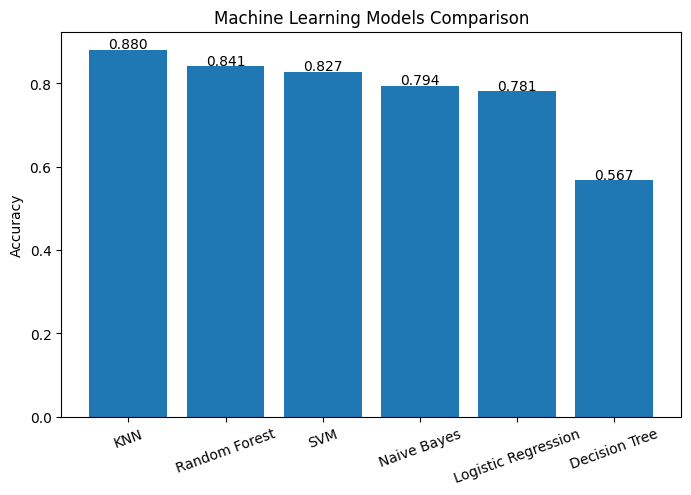

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Machine Learning Models Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.003, f"{v:.3f}", ha="center")

plt.show()

## Macro F1 Comparison

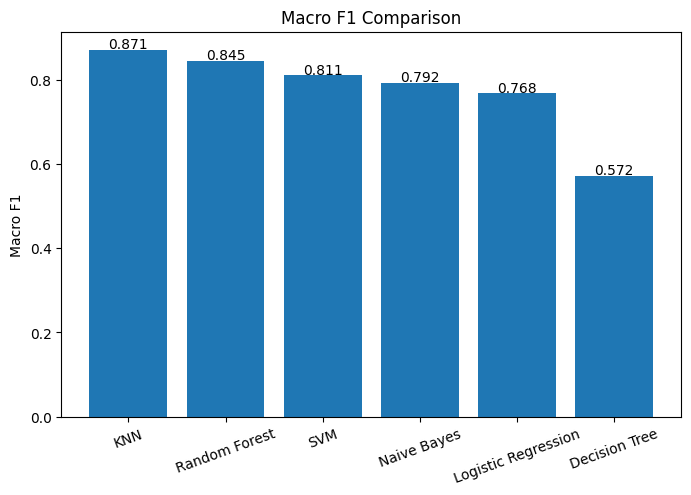

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Macro F1"]
)

plt.title("Macro F1 Comparison")

plt.ylabel("Macro F1")

plt.xticks(rotation=20)

for i, v in enumerate(results_df["Macro F1"]):
    plt.text(i, v+0.003, f"{v:.3f}", ha="center")

plt.show()

Precision Comparison

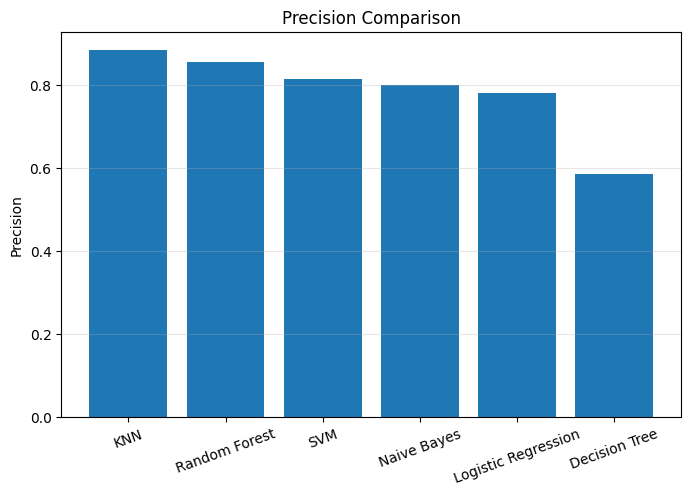

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Precision"])

plt.title("Precision Comparison")

plt.ylabel("Precision")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.show()

Recall Comparison

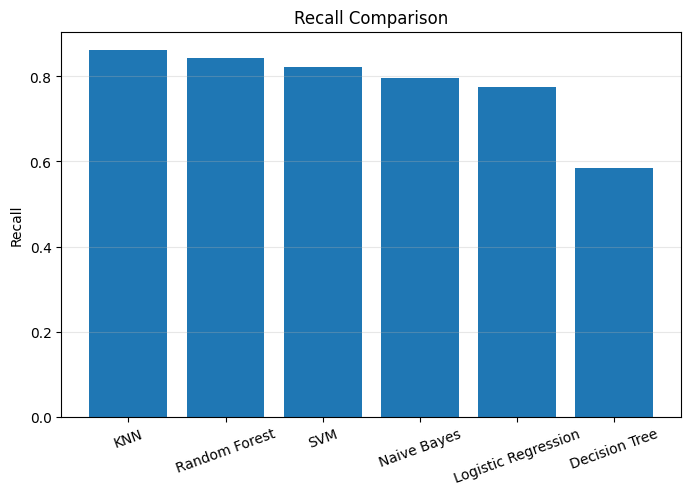

In [44]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Recall"])

plt.title("Recall Comparison")

plt.ylabel("Recall")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.show()

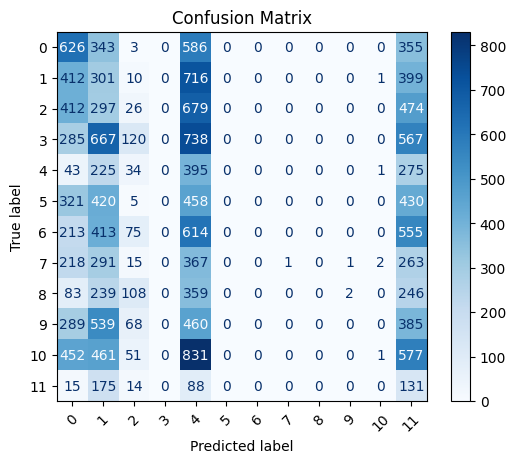

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(StandardScaler().fit_transform(X))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

In [50]:
report = pd.DataFrame(
    classification_report(
        y_true_all,
        y_pred_all,
        output_dict=True
    )
).transpose()

report

,precision,recall,f1-score,support
0,0.823232,0.937271,0.876558,1913.000000
1,0.834771,0.684067,0.751943,1839.000000
2,0.854610,0.510593,0.639257,1888.000000
3,0.869122,0.933109,0.899980,2377.000000
4,0.674395,0.687564,0.680916,973.000000
5,0.950865,0.840881,0.892498,1634.000000
6,0.943396,0.802139,0.867052,1870.000000
7,0.700163,0.740069,0.719563,1158.000000
8,0.643253,0.671167,0.656914,1037.000000
9,0.573746,0.893739,0.698855,1741.000000


In [51]:
results_df.to_csv(
    "PAMAP2_ML_results.csv",
    index=False
)

In [28]:
import os
os.environ.pop('PIP_PREFIX', None)

import sys

!{sys.executable} -m pip install --no-index --user --ignore-installed xgboost

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic/xgboost-3.2.0+computecanada-py3-none-linux_x86_64.whl
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic/numpy-2.4.2+computecanada-cp311-cp311-linux_x86_64.whl (from xgboost)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic/scipy-1.17.0+computecanada-cp311-cp311-linux_x86_64.whl (from xgboost)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [xgboost]m2/3 [xgboost]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.


In [52]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [53]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

In [54]:
y_true_all = []
y_pred_all = []

for train_idx, test_idx in logo.split(X, y, groups):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", xgb_model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true_all, y_pred_all)

precision = precision_score(
    y_true_all,
    y_pred_all,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true_all,
    y_pred_all,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true_all,
    y_pred_all,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

Accuracy : 0.8176
Precision: 0.8271
Recall   : 0.8017
Macro F1 : 0.8065


<Figure size 1000x800 with 0 Axes>

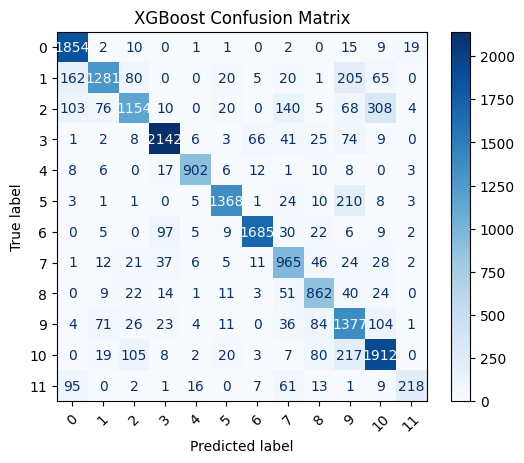

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [57]:
report = pd.DataFrame(
    classification_report(
        y_true_all,
        y_pred_all,
        output_dict=True
    )
).transpose()

report

,precision,recall,f1-score,support
0,0.831017,0.969158,0.894788,1913.000000
1,0.863208,0.696574,0.770990,1839.000000
2,0.807558,0.611229,0.695809,1888.000000
3,0.911877,0.901136,0.906475,2377.000000
4,0.951477,0.927030,0.939094,973.000000
5,0.928087,0.837209,0.880309,1634.000000
6,0.939766,0.901070,0.920011,1870.000000
7,0.700290,0.833333,0.761041,1158.000000
8,0.744387,0.831244,0.785421,1037.000000
9,0.613363,0.790925,0.690918,1741.000000
